<a href="https://colab.research.google.com/github/Ilham-svg/Zomato_Data_analysis/blob/main/Zomato_Data_Anlysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data Analysis Datasets/Zomato-data-.csv')
print(df.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [ ]:
def handleRate(value):
  value=str(value).split('/')
  value = value[0]
  return float(value)

df['rate'] = df['rate'].apply(handleRate)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [ ]:
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


Text(0.5, 0, 'Type of resturent')

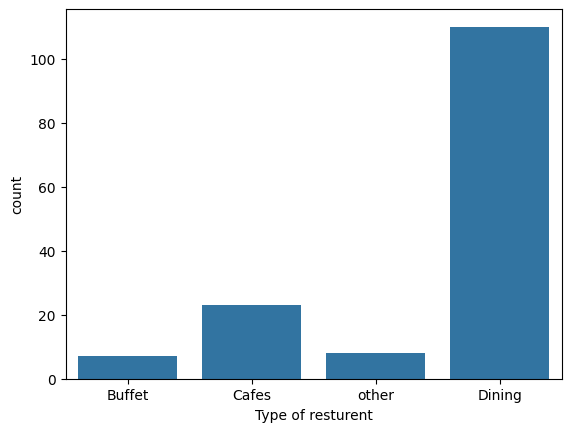

In [ ]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("Type of resturent")

Text(0, 0.5, 'Votes')

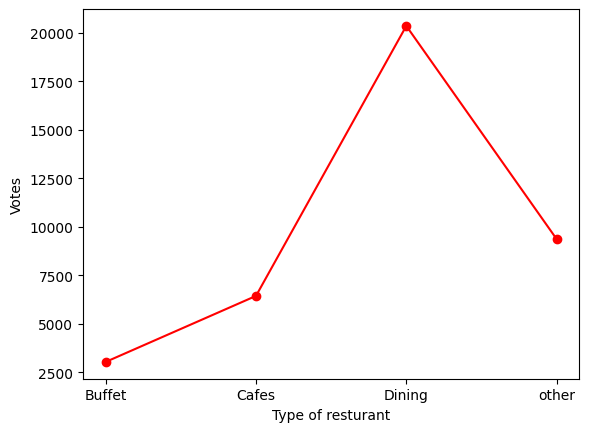

In [ ]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
#result = pd.DataFrame({'Votes': grouped_data})
plt.plot(grouped_data, c = 'red', marker = 'o')
plt.xlabel('Type of resturant')
plt.ylabel('Votes')

In [ ]:
max_votes = df['votes'].max()
print('Resturant(s) with maximum votes:',max_votes)
df.loc[df['votes'] == max_votes, 'name']

Resturant(s) with maximum votes: 4884


,name
38,Empire Restaurant


<Axes: xlabel='online_order', ylabel='count'>

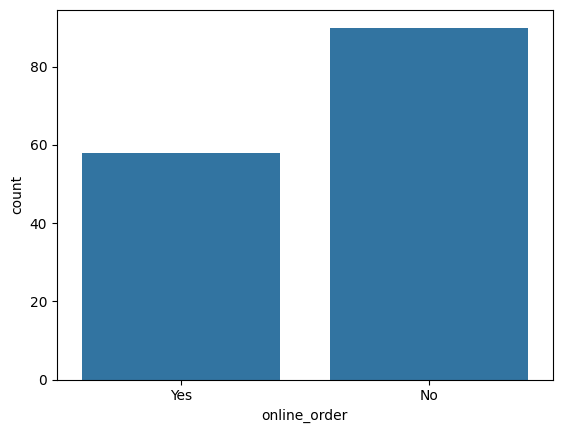

In [ ]:
sns.countplot(x=df['online_order'])

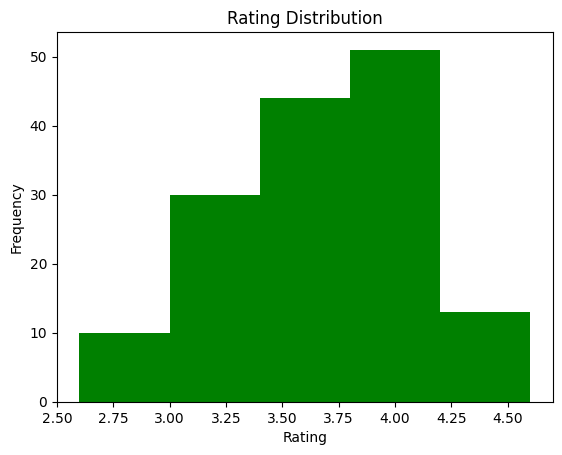

In [ ]:
plt.hist(df['rate'],bins = 5,color = 'green')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Rating Distribution')
plt.show()

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

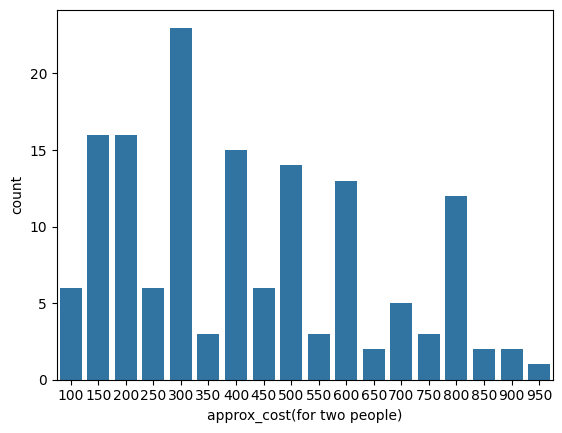

In [ ]:
couple_data = df['approx_cost(for two people)']
sns.countplot(x=couple_data)

<Axes: xlabel='online_order', ylabel='rate'>

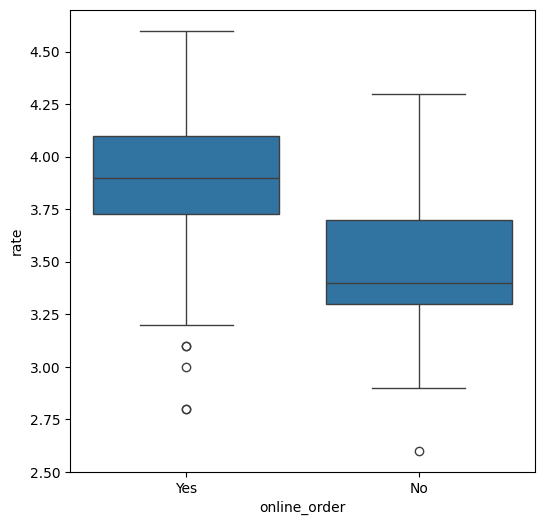

In [ ]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order',y = 'rate',data = df)

<Axes: xlabel='online_order', ylabel='rate'>

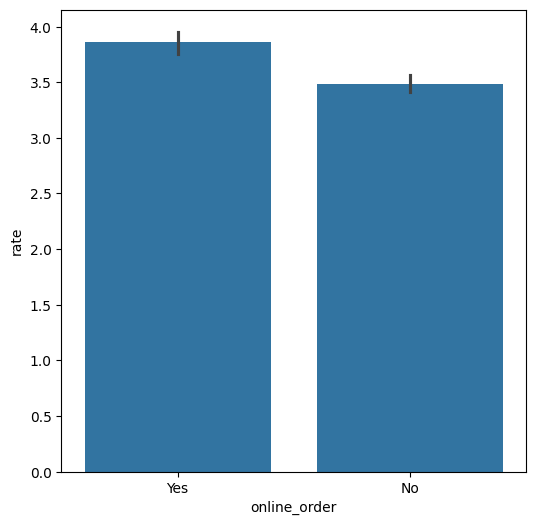

In [ ]:
plt.figure(figsize = (6,6))
sns.barplot(x = 'online_order',y ='rate', data = df)

Text(0, 0.5, 'rate')

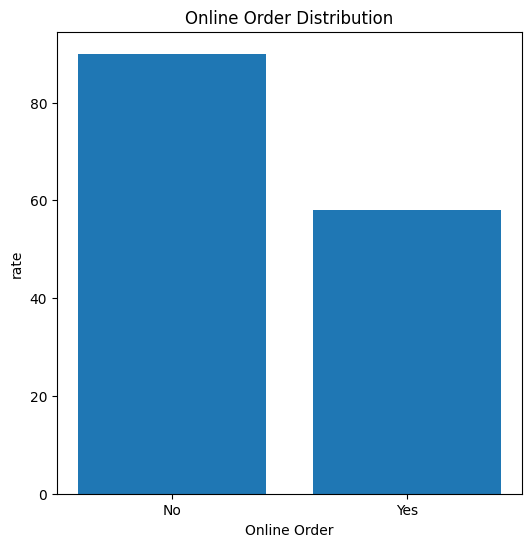

In [ ]:
plt.figure(figsize = (6,6))
counts = df['online_order'].value_counts()
plt.bar(counts.index,height = counts.values)
plt.title('Online Order Distribution')
plt.xlabel('Online Order')
plt.ylabel('rate')

Text(0, 0.5, 'Rating')

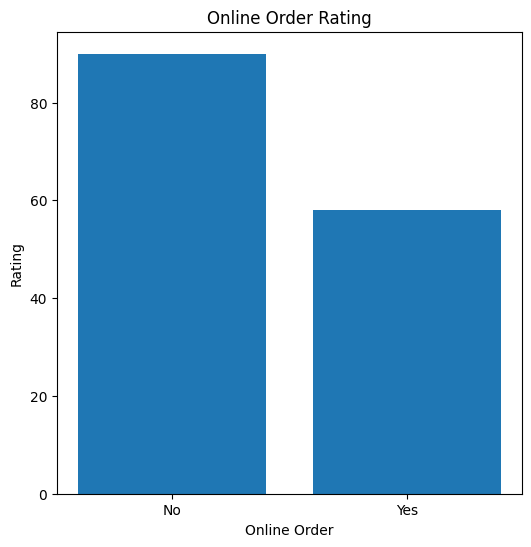

In [ ]:
plt.figure(figsize = (6,6))
rating_points = df.groupby(['online_order'])['rate'].count()
plt.bar(rating_points.index,height = rating_points.values)
plt.title('Online Order Rating')
plt.xlabel('Online Order')
plt.ylabel('Rating')

In [ ]:
df.tail()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining
147,Vijayalakshmi,Yes,No,3.9,47,200,Dining


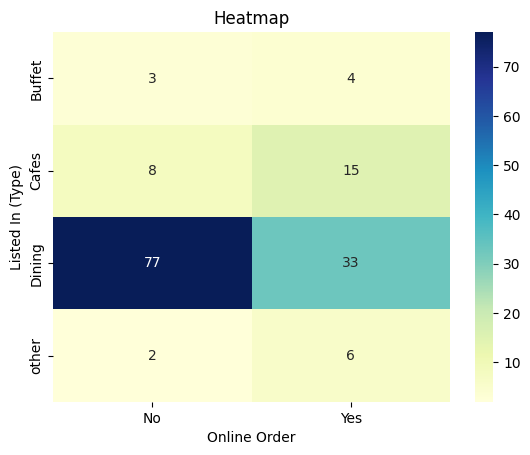

In [ ]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

In [ ]:
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [ ]:
from scipy.stats import f_oneway
f_statistic, p_value = f_oneway(df[df['online_order'] == 'Yes']['rate'], df[df['online_order'] == 'No']['rate'])
print("F-statistic:", f_statistic)
print("P-value:", p_value)

F-statistic: 37.3959702592853
P-value: 8.3909922436449e-09


In [ ]:
if p_value < 0.05:
    print("There is a significant difference in rating between online orders and no online orders.")
else:
    print("There is no significant difference in rating between online orders and no online orders.")

There is a significant difference in rating between online orders and no online orders.


### ANOVA Test for 'rate' across 'listed_in(type)'

First, let's perform an ANOVA test to see if there's an overall significant difference in ratings across the different types of restaurants listed.

In [ ]:
from scipy.stats import f_oneway

# Get unique categories for 'listed_in(type)'
categories = df['listed_in(type)'].unique()

# Prepare data for ANOVA: a list of 'rate' series for each category
data_for_anova = [df['rate'][df['listed_in(type)'] == cat] for cat in categories]

# Perform one-way ANOVA
f_statistic_type, p_value_type = f_oneway(*data_for_anova)

print(f"F-statistic: {f_statistic_type}")
print(f"P-value: {p_value_type}")

if p_value_type < 0.05:
    print("\nThere is a significant difference in rating among different restaurant types (listed_in(type)).")
else:
    print("\nThere is no significant difference in rating among different restaurant types (listed_in(type)).")

F-statistic: 3.8047435256635143
P-value: 0.011606382419056307

There is a significant difference in rating among different restaurant types (listed_in(type)).


### Post-hoc Test (Tukey's HSD)

Since the ANOVA test indicates a significant difference, we'll perform a post-hoc test (Tukey's HSD) to determine exactly which pairs of restaurant types have significantly different ratings.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD post-hoc test
tukey_result = pairwise_tukeyhsd(endog=df['rate'], groups=df['listed_in(type)'], alpha=0.05)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Buffet  Cafes  -0.0776 0.9676 -0.5166 0.3613  False
Buffet Dining   -0.271 0.2885 -0.6674 0.1254  False
Buffet  other   0.0696  0.986 -0.4567 0.5959  False
 Cafes Dining  -0.1934 0.1407 -0.4266 0.0398  False
 Cafes  other   0.1473 0.7957 -0.2701 0.5647  False
Dining  other   0.3407 0.0859 -0.0317 0.7131  False
---------------------------------------------------


The Tukey's HSD post-hoc test results above show the comparisons between each pair of `listed_in(type)` categories.

*   **`reject`**: A `True` value in this column indicates that the null hypothesis (that the means of the two groups are equal) is rejected, meaning there is a statistically significant difference between the means of those two groups at the 0.05 significance level.
*   **`p-adj`**: The adjusted p-value for the comparison. If `p-adj` is less than 0.05, the difference is significant.

<function matplotlib.pyplot.show(close=None, block=None)>

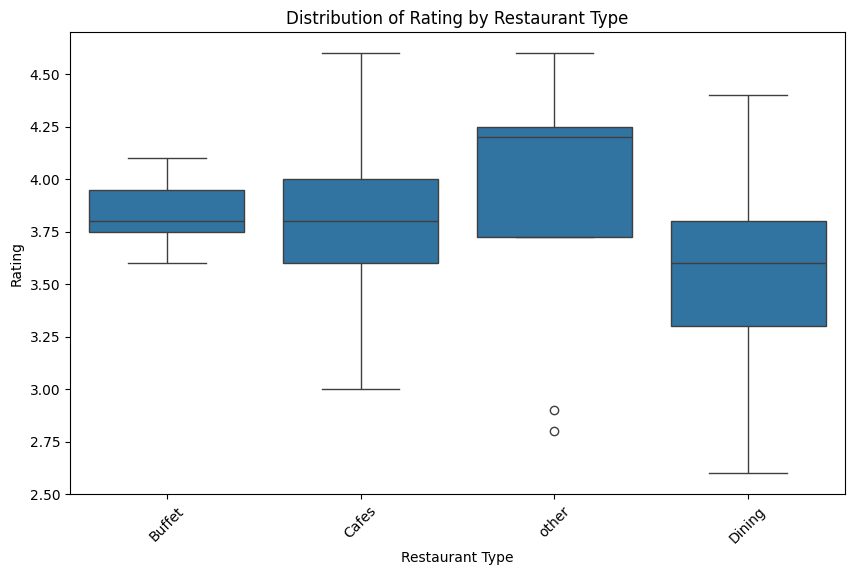

In [ ]:
#create a boxplot to visualize distribution of 'rate' by 'listed_in(type)'
plt.figure(figsize=(10,6))
sns.boxplot(x='listed_in(type)', y='rate', data=df)
plt.title('Distribution of Rating by Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.show

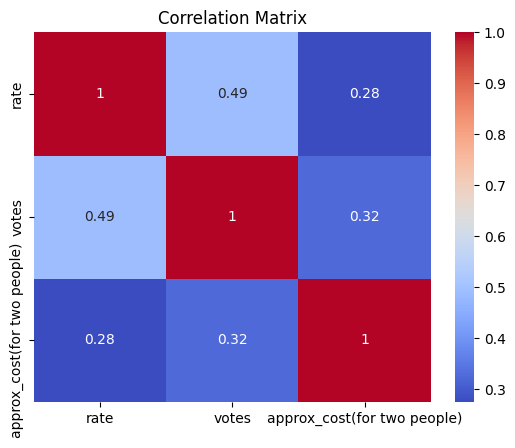

In [ ]:
#correlation between 'rate', 'votes' and 'approx_cost(for two people)'
correlation_matrix = df[['rate','votes','approx_cost(for two people)']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

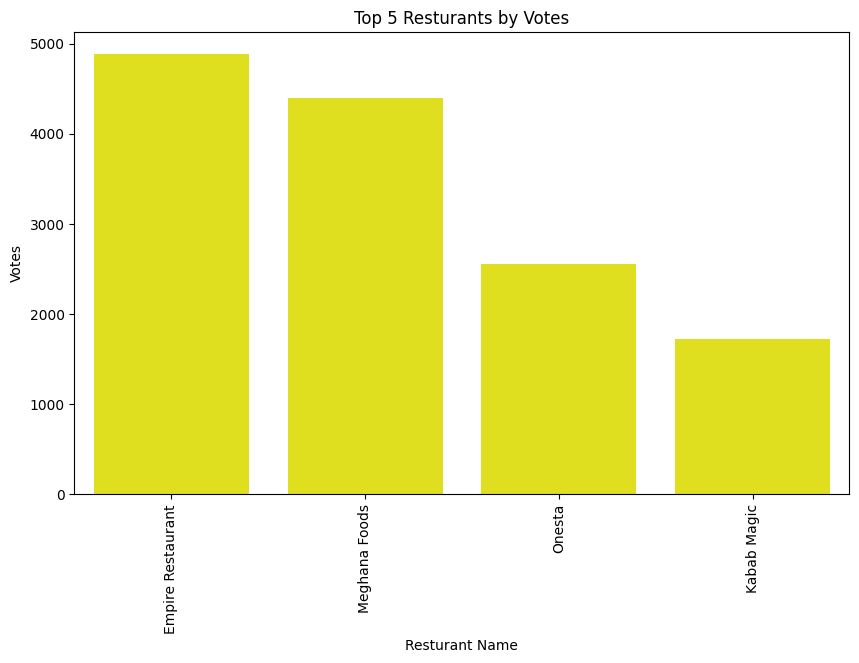

In [ ]:
#identify the top 5 resturants by 'votes' using a bar chart'
top_5_resturants = df.nlargest(5, 'votes')
plt.figure(figsize=(10,6))
sns.barplot(x='name', y='votes', data=top_5_resturants, color = 'yellow')
plt.title('Top 5 Resturants by Votes')
plt.xlabel('Resturant Name')
plt.ylabel('Votes')
plt.xticks(rotation=90)
plt.show()


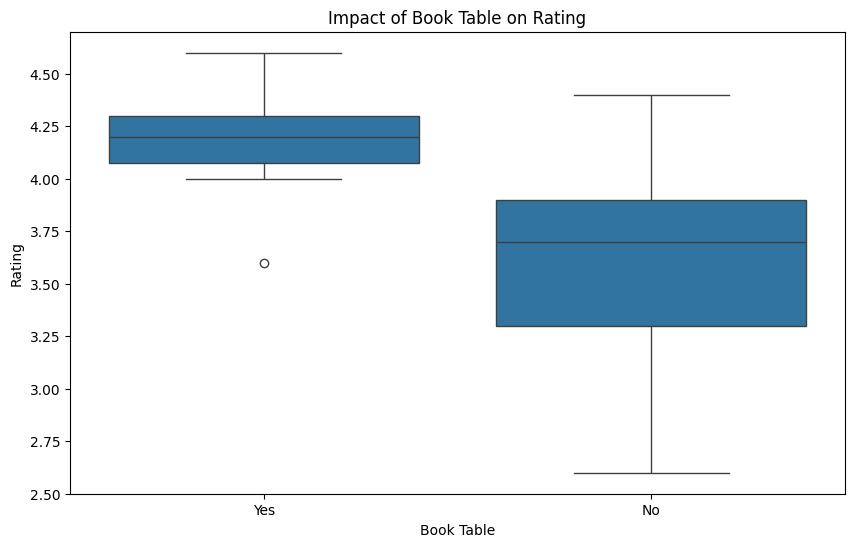

In [ ]:
#analyze the impact of 'book_table' on 'rate' and 'votes'
plt.figure(figsize=(10,6))
sns.boxplot(x='book_table',y='rate',data=df)
plt.title('Impact of Book Table on Rating')
plt.xlabel('Book Table')
plt.ylabel('Rating')
plt.show()

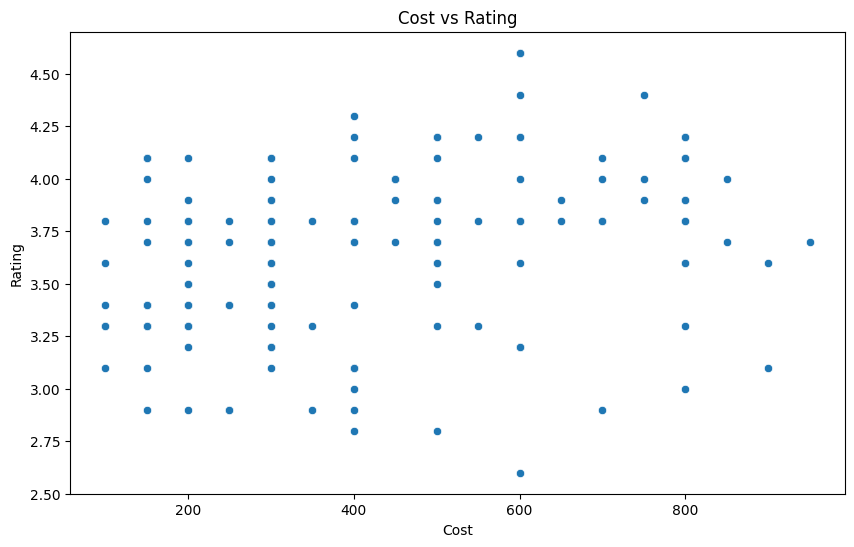

In [ ]:
#visualize 'approx_cos(for two people)' vs 'rate'
plt.figure(figsize=(10,6))
sns.scatterplot(x='approx_cost(for two people)',y='rate',data=df)
plt.title('Cost vs Rating')
plt.xlabel('Cost')
plt.ylabel('Rating')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

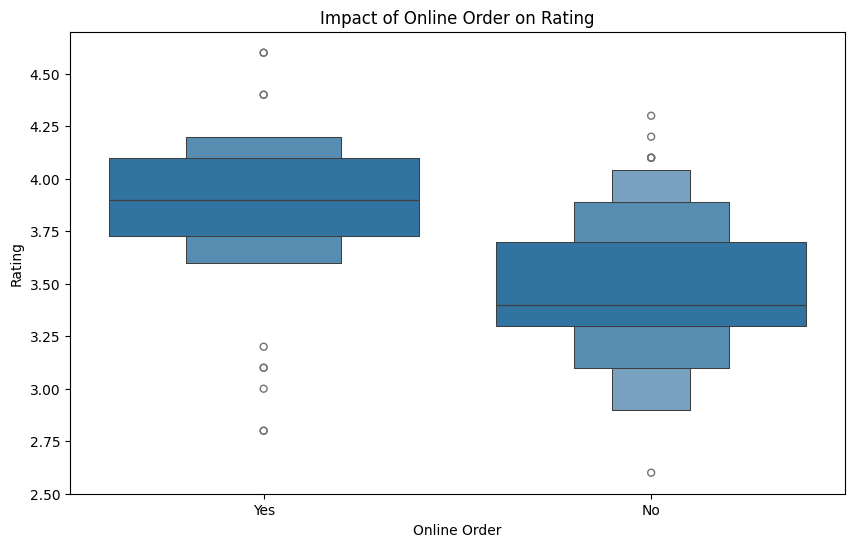

In [ ]:
#compare 'rate' and 'votes' for resturants with and without 'online_order'
plt.figure(figsize=(10,6))
sns.boxenplot(x='online_order',y='rate',data=df)
plt.title('Impact of Online Order on Rating')
plt.xlabel('Online Order')
plt.ylabel('Rating')
plt.show